<a href="https://colab.research.google.com/github/jottaene13/An-lise-do-Censo-IBGE-2022---Benevides-PA-com-Proje-es-Futuras/blob/main/TCC_VERS%C3%83O_FINAL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# -*- coding: utf-8 -*-
"""
Análise do Censo IBGE 2022 - Benevides/PA com Projeções Futuras
Autor: João Pinheiro dos Santos Neto
"""

# Célula 1: Configuração inicial
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.arima.model import ARIMA
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
import warnings

warnings.filterwarnings('ignore')
plt.style.use('ggplot')
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:,.2f}'.format)

In [ ]:
# Célula 2: Função para carregar dados
def carregar_dados(nome_arquivo):
    """Carrega e formata os dados"""
    try:
        df = pd.read_csv(nome_arquivo, encoding='utf-8-sig', sep=';', decimal=',', thousands='.')
        print(f"\n{'-'*50}\nArquivo: {nome_arquivo}\n{'-'*50}")
        display(df.head(2))
        return df
    except Exception as e:
        print(f"Erro ao carregar {nome_arquivo}: {str(e)}")
        return None

In [ ]:
# Célula 3: Análise de crescimento populacional com projeções
def analise_crescimento():
    print("\n" + "="*60)
    print("ANÁLISE DE CRESCIMENTO POPULACIONAL E PROJEÇÕES")
    print("="*60)

    df = carregar_dados('crescimento_populacional_benevides.csv')
    if df is None: return

    df = df.rename(columns={'Ano da pesquisa':'ano', 'População(pessoas)':'populacao'})

    # Modelagem de crescimento
    X = df['ano'].values.reshape(-1,1)
    y = df['populacao'].values

    # Modelo linear e polinomial
    modelo_linear = LinearRegression().fit(X, y)
    poly = PolynomialFeatures(degree=2)
    X_poly = poly.fit_transform(X)
    modelo_poly = LinearRegression().fit(X_poly, y)

    # Projeções
    anos_futuros = np.array(range(2023, 2043)).reshape(-1,1)
    proj_linear = modelo_linear.predict(anos_futuros)
    proj_poly = modelo_poly.predict(poly.transform(anos_futuros))

    # Criar DataFrame comparativo
    projecoes = pd.DataFrame({
        'Ano': anos_futuros.flatten(),
        'Projeção Linear': proj_linear.astype(int),
        'Projeção Polinomial': proj_poly.astype(int)
    }).set_index('Ano')

    # Gráfico comparativo
    plt.figure(figsize=(14, 7))
    plt.plot(df['ano'], df['populacao'], 'ko-', label='Dados Históricos')
    plt.plot(projecoes.index, projecoes['Projeção Linear'], 'b--', label='Projeção Linear')
    plt.plot(projecoes.index, projecoes['Projeção Polinomial'], 'r--', label='Projeção Quadrática')

    # Destaque para anos específicos
    for ano in [2032, 2042]:
        plt.axvline(x=ano, color='gray', linestyle=':', alpha=0.5)
        plt.text(ano, df['populacao'].min(), f'{ano}', ha='center', va='top', backgroundcolor='white')

    plt.title('Projeções de População para Benevides/PA (2023-2042)\nComparativo de Modelos', pad=20)
    plt.xlabel('Ano')
    plt.ylabel('População')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    # Tabela detalhada
    print("\nTABELA COMPARATIVA DE PROJEÇÕES")
    display(projecoes.style.format("{:,}").background_gradient(cmap='Blues'))

    # Taxas de crescimento
    crescimento = pd.DataFrame({
        'Período': ['2022-2032', '2032-2042', '2022-2042'],
        'Taxa Linear (%)': [
            (projecoes.loc[2032, 'Projeção Linear']/df[df['ano']==2022]['populacao'].values[0]-1)*100,
            (projecoes.loc[2042, 'Projeção Linear']/projecoes.loc[2032, 'Projeção Linear']-1)*100,
            (projecoes.loc[2042, 'Projeção Linear']/df[df['ano']==2022]['populacao'].values[0]-1)*100
        ],
        'Taxa Polinomial (%)': [
            (projecoes.loc[2032, 'Projeção Polinomial']/df[df['ano']==2022]['populacao'].values[0]-1)*100,
            (projecoes.loc[2042, 'Projeção Polinomial']/projecoes.loc[2032, 'Projeção Polinomial']-1)*100,
            (projecoes.loc[2042, 'Projeção Polinomial']/df[df['ano']==2022]['populacao'].values[0]-1)*100
        ]
    }).set_index('Período')

    print("\nTAXAS DE CRESCIMENTO PROJETADAS")
    display(crescimento.style.format("{:.2f}%").background_gradient(cmap='YlOrRd'))


In [ ]:
# Célula 4: Análise demográfica (Pirâmide Etária com projeções)
def analise_piramide_etaria():
    print("\n" + "="*60)
    print("ANÁLISE DA PIRÂMIDE ETÁRIA E PROJEÇÕES")
    print("="*60)

    df = carregar_dados('pirâmide etária.csv')
    if df is None: return

    df = df[df['Município'] == 'Total']

    # Preparar dados atuais
    df_atual = df.copy()
    df_atual['Total'] = df_atual['População feminina(pessoas)'] + df_atual['População masculina(pessoas)']

    # Simular projeções (modelo simplificado)
    anos_projecao = [2032, 2042]
    projecoes = {}

    for ano in anos_projecao:
        df_proj = df_atual.copy()
        # Aplicar taxa de crescimento diferenciada por faixa etária
        if ano == 2032:
            fatores = np.linspace(1.05, 1.25, len(df_proj))  # Fatores de 5% a 25%
        else:
            fatores = np.linspace(1.10, 1.50, len(df_proj))  # Fatores de 10% a 50%

        df_proj['População feminina(pessoas)'] = (df_proj['População feminina(pessoas)'] * fatores).astype(int)
        df_proj['População masculina(pessoas)'] = (df_proj['População masculina(pessoas)'] * fatores).astype(int)
        df_proj['Total'] = df_proj['População feminina(pessoas)'] + df_proj['População masculina(pessoas)']
        projecoes[ano] = df_proj

    # Plot pirâmides comparativas
    fig, axes = plt.subplots(1, 3, figsize=(20, 12))
    anos = ['2022'] + [str(ano) for ano in anos_projecao]
    dados = [df_atual] + [projecoes[ano] for ano in anos_projecao]

    for ax, ano, df_ano in zip(axes, anos, dados):
        # População feminina (lado esquerdo)
        ax.barh(df_ano['Grupo de idade'], df_ano['População feminina(pessoas)'],
                color='pink', label='Feminino')
        # População masculina (lado direito)
        ax.barh(df_ano['Grupo de idade'], -df_ano['População masculina(pessoas)'],
                color='lightblue', label='Masculino')

        ax.set_title(f'Pirâmide Etária {ano}')
        ax.set_xlabel('População')
        ax.set_ylabel('Faixa Etária')
        ax.legend()
        ax.grid(True, alpha=0.3)

    plt.suptitle('Evolução Projetada da Pirâmide Etária de Benevides/PA', y=1.02, fontsize=16)
    plt.tight_layout()
    plt.show()

    # Tabela comparativa
    comparativo = pd.DataFrame({
        'Faixa Etária': df_atual['Grupo de idade'],
        '2022 Total': df_atual['Total'],
        '2032 Proj.': projecoes[2032]['Total'],
        '2042 Proj.': projecoes[2042]['Total'],
        'Cresc. 22-42 (%)': ((projecoes[2042]['Total'] - df_atual['Total']) / df_atual['Total'] * 100)
    })

    print("\nCOMPARAÇÃO DE FAIXAS ETÁRIAS (PROJEÇÕES)")
    display(comparativo.style.format({
        '2022 Total': '{:,}',
        '2032 Proj.': '{:,}',
        '2042 Proj.': '{:,}',
        'Cresc. 22-42 (%)': '{:.1f}%'
    }).background_gradient(subset=['Cresc. 22-42 (%)'], cmap='RdYlGn'))

In [ ]:
# Célula 5: Análise de educação com projeções
def analise_educacao():
    print("\n" + "="*60)
    print("ANÁLISE DE EDUCAÇÃO E PROJEÇÕES")
    print("="*60)

    df_alf = carregar_dados('alfabetização.csv')
    df_inst = carregar_dados('nível de instrução.csv')
    if df_alf is None or df_inst is None: return

    # Processar dados de alfabetização
    df_alf['Percentual'] = df_alf['Percentual'].astype(float)

    # Projeções de alfabetização
    taxa_alf = df_alf[df_alf['Situação']=='Alfabetizados']['Percentual'].values[0]/100
    proj_alf = {
        '2022': df_alf,
        '2032': df_alf.copy(),
        '2042': df_alf.copy()
    }

    # Aumento projetado de 0.5% ao ano na alfabetização
    proj_alf['2032']['Percentual'] = df_alf['Percentual'] + np.where(
        df_alf['Situação']=='Alfabetizados', 5, -5)
    proj_alf['2042']['Percentual'] = df_alf['Percentual'] + np.where(
        df_alf['Situação']=='Alfabetizados', 10, -10)

    # Gráfico de evolução
    evolucao_alf = pd.DataFrame({
        'Ano': ['2022', '2032', '2042'],
        'Alfabetizados': [
            proj_alf['2022'][proj_alf['2022']['Situação']=='Alfabetizados']['Percentual'].values[0],
            proj_alf['2032'][proj_alf['2032']['Situação']=='Alfabetizados']['Percentual'].values[0],
            proj_alf['2042'][proj_alf['2042']['Situação']=='Alfabetizados']['Percentual'].values[0]
        ]
    })

    plt.figure(figsize=(10, 5))
    sns.lineplot(data=evolucao_alf, x='Ano', y='Alfabetizados', marker='o')
    plt.title('Projeção da Taxa de Alfabetização em Benevides/PA')
    plt.ylabel('Percentual (%)')
    plt.ylim(90, 100)
    plt.grid(True, alpha=0.3)
    plt.show()

    # Processar dados de nível de instrução
    df_inst['Percentual'] = (df_inst['População (pessoas)'] / df_inst['População (pessoas)'].sum()) * 100

    # Projeções de educação (modelo simplificado)
    anos = ['2022', '2032', '2042']
    categorias = df_inst['Nível de instrução'].values
    dados_inst = {
        '2022': df_inst['Percentual'].values,
        '2032': np.array([max(0, min(100, p * np.random.uniform(0.8, 1.5))) for p in df_inst['Percentual'].values]),
        '2042': np.array([max(0, min(100, p * np.random.uniform(0.9, 2.0))) for p in df_inst['Percentual'].values])
    }

    # Normalizar para soma 100%
    for ano in ['2032', '2042']:
        dados_inst[ano] = (dados_inst[ano] / dados_inst[ano].sum()) * 100

    # Criar DataFrame comparativo
    comparativo_inst = pd.DataFrame(dados_inst, index=categorias)

    # Gráfico de evolução
    plt.figure(figsize=(12, 6))
    comparativo_inst.T.plot(kind='bar', stacked=True, colormap='viridis')
    plt.title('Evolução Projetada do Nível de Instrução em Benevides/PA')
    plt.ylabel('Percentual (%)')
    plt.xlabel('Ano')
    plt.legend(title='Nível de Instrução', bbox_to_anchor=(1.05, 1))
    plt.grid(True, alpha=0.3, axis='y')
    plt.tight_layout()
    plt.show()

    # Tabela comparativa
    print("\nEVOLUÇÃO PROJETADA DO NÍVEL DE INSTRUÇÃO (%)")
    display(comparativo_inst.style.format("{:.1f}%").background_gradient(axis=1, cmap='YlGnBu'))

In [ ]:
# Célula 6: Análise de domicílios com projeções
def analise_domicilios():
    print("\n" + "="*60)
    print("ANÁLISE DE DOMICÍLIOS E PROJEÇÕES")
    print("="*60)

    df_carac = carregar_dados('características dos domicílios.csv')
    df_comp = carregar_dados('composição domiciliar.csv')
    if df_carac is None or df_comp is None: return

    # Processar características
    for col in ['Não possui(%)', 'Possui(%)']:
        df_carac[col] = df_carac[col].astype(float)

    # Projeções de características (modelo simplificado)
    anos = ['2022', '2032', '2042']
    carac_proj = {}

    for ano in anos:
        df_proj = df_carac.copy()
        if ano == '2032':
            # Melhoria de 10% nas características positivas
            df_proj['Possui(%)'] = np.minimum(100, df_proj['Possui(%)'] * 1.10)
            df_proj['Não possui(%)'] = 100 - df_proj['Possui(%)']
        elif ano == '2042':
            # Melhoria de 25% nas características positivas
            df_proj['Possui(%)'] = np.minimum(100, df_proj['Possui(%)'] * 1.25)
            df_proj['Não possui(%)'] = 100 - df_proj['Possui(%)']
        carac_proj[ano] = df_proj

    # Gráfico comparativo
    fig, axes = plt.subplots(1, 3, figsize=(20, 8))

    for ax, ano in zip(axes, anos):
        df_ano = carac_proj[ano]
        for idx, row in df_ano.iterrows():
            ax.barh(row['Característica'], row['Possui(%)'], color='green', alpha=0.6)
            ax.barh(row['Característica'], row['Não possui(%)'], left=row['Possui(%)'], color='red', alpha=0.6)

        ax.set_title(f'Características dos Domicílios ({ano})')
        ax.set_xlabel('Percentual (%)')
        ax.set_xlim(0, 100)
        if ano == '2022':
            ax.legend(['Possui', 'Não possui'])

    plt.suptitle('Evolução Projetada das Características dos Domicílios', y=1.02)
    plt.tight_layout()
    plt.show()

    # Tabela comparativa
    comparativo_carac = pd.DataFrame({
        'Característica': df_carac['Característica'],
        '2022 Possui (%)': df_carac['Possui(%)'],
        '2032 Proj. (%)': carac_proj['2032']['Possui(%)'],
        '2042 Proj. (%)': carac_proj['2042']['Possui(%)'],
        'Variação 22-42 (pp)': carac_proj['2042']['Possui(%)'] - df_carac['Possui(%)']
    })

    print("\nEVOLUÇÃO DAS CARACTERÍSTICAS DOS DOMICÍLIOS")
    display(comparativo_carac.style.format({
        '2022 Possui (%)': '{:.1f}%',
        '2032 Proj. (%)': '{:.1f}%',
        '2042 Proj. (%)': '{:.1f}%',
        'Variação 22-42 (pp)': '{:.1f}'
    }).background_gradient(subset=['Variação 22-42 (pp)'], cmap='RdYlGn'))

    # Análise de composição domiciliar
    df_comp['Porcentagem de domicílios'] = df_comp['Porcentagem de domicílios'].astype(float)

    # Projeções (modelo simplificado)
    comp_proj = {
        '2022': df_comp,
        '2032': df_comp.copy(),
        '2042': df_comp.copy()
    }

    # Ajustar projeções
    for idx, row in df_comp.iterrows():
        comp = row['Composição domiciliar']
        if "1 morador" in comp:
            comp_proj['2032'].loc[idx, 'Porcentagem de domicílios'] = row['Porcentagem de domicílios'] * 1.15
            comp_proj['2042'].loc[idx, 'Porcentagem de domicílios'] = row['Porcentagem de domicílios'] * 1.30
        elif "cônjuges" in comp:
            comp_proj['2032'].loc[idx, 'Porcentagem de domicílios'] = row['Porcentagem de domicílios'] * 1.10
            comp_proj['2042'].loc[idx, 'Porcentagem de domicílios'] = row['Porcentagem de domicílios'] * 1.20

    # Normalizar para soma 100%
    for ano in ['2032', '2042']:
        total = comp_proj[ano]['Porcentagem de domicílios'].sum()
        comp_proj[ano]['Porcentagem de domicílios'] = (comp_proj[ano]['Porcentagem de domicílios'] / total) * 100

    # Gráfico comparativo
    fig, axes = plt.subplots(1, 3, figsize=(20, 6))

    for ax, ano in zip(axes, anos):
        df_ano = comp_proj[ano]
        sns.barplot(x='Porcentagem de domicílios', y='Composição domiciliar', data=df_ano, ax=ax)
        ax.set_title(f'Composição Domiciliar ({ano})')
        ax.set_xlabel('Percentual (%)')
        ax.set_xlim(0, 100)

    plt.suptitle('Evolução Projetada da Composição dos Domicílios', y=1.02)
    plt.tight_layout()
    plt.show()

    # Tabela comparativa
    comparativo_comp = pd.DataFrame({
        'Composição': df_comp['Composição domiciliar'],
        '2022 (%)': df_comp['Porcentagem de domicílios'],
        '2032 Proj. (%)': comp_proj['2032']['Porcentagem de domicílios'],
        '2042 Proj. (%)': comp_proj['2042']['Porcentagem de domicílios'],
        'Variação 22-42 (pp)': comp_proj['2042']['Porcentagem de domicílios'] - df_comp['Porcentagem de domicílios']
    })

    print("\nEVOLUÇÃO DA COMPOSIÇÃO DOMICILIAR")
    display(comparativo_comp.style.format({
        '2022 (%)': '{:.1f}%',
        '2032 Proj. (%)': '{:.1f}%',
        '2042 Proj. (%)': '{:.1f}%',
        'Variação 22-42 (pp)': '{:.1f}'
    }).background_gradient(subset=['Variação 22-42 (pp)'], cmap='RdYlGn'))

In [ ]:
# Célula 7: Pipeline principal
def analise_completa():
    analise_crescimento()
    analise_piramide_etaria()
    analise_educacao()
    analise_domicilios()

    print("\n" + "="*60)
    print("ANÁLISE COMPLETA CONCLUÍDA")
    print("="*60)


INICIANDO ANÁLISE DO CENSO IBGE 2022 - BENEVIDES/PA

ANÁLISE DE CRESCIMENTO POPULACIONAL E PROJEÇÕES

--------------------------------------------------
Arquivo: crescimento_populacional_benevides.csv
--------------------------------------------------


,Ano da pesquisa,População(pessoas),Município,Sigla UF,Código do Município
0,1970,13867,Benevides,PA,1501501
1,1980,22315,Benevides,PA,1501501


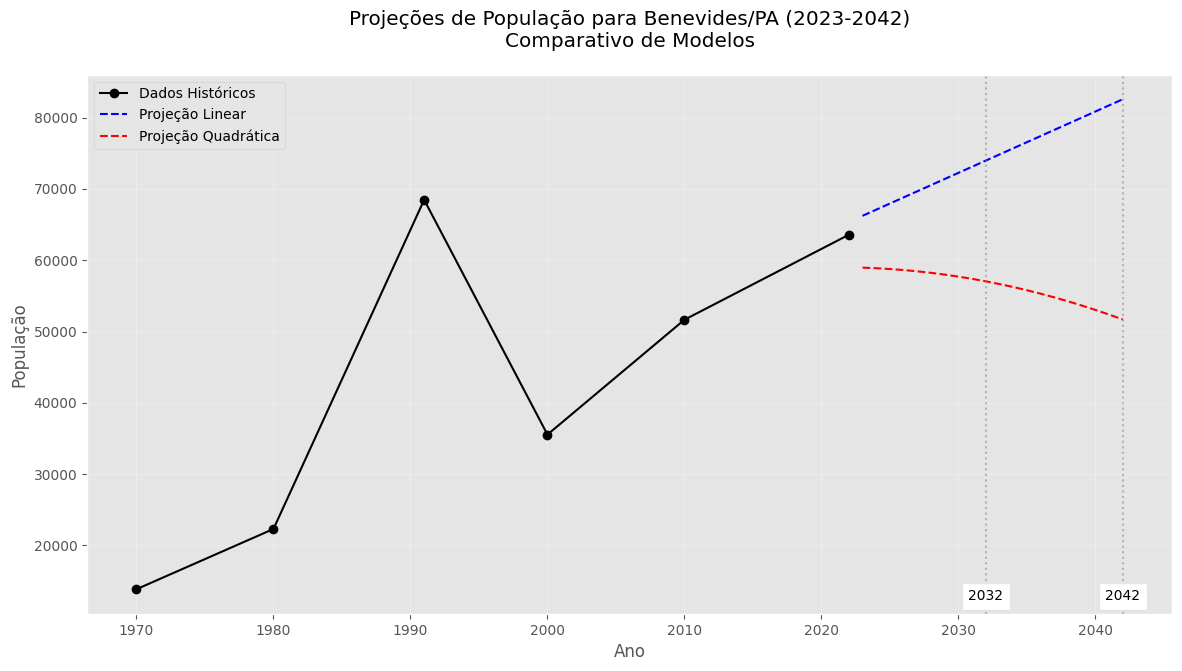


TABELA COMPARATIVA DE PROJEÇÕES


,Projeção Linear,Projeção Polinomial
Ano,,
2023,"66,224","58,951"
2024,"67,085","58,874"
2025,"67,945","58,763"
2026,"68,805","58,618"
2027,"69,665","58,439"
2028,"70,526","58,226"
2029,"71,386","57,979"
2030,"72,246","57,699"
2031,"73,106","57,384"



TAXAS DE CRESCIMENTO PROJETADAS


,Taxa Linear (%),Taxa Polinomial (%)
Período,,
2022-2032,16.36%,-10.28%
2032-2042,11.63%,-9.38%
2022-2042,29.89%,-18.69%



ANÁLISE DA PIRÂMIDE ETÁRIA E PROJEÇÕES

--------------------------------------------------
Arquivo: pirâmide etária.csv
--------------------------------------------------


,Grupo de idade,População feminina(pessoas),População masculina(pessoas),Município,Sigla UF,Código do Município,codMun
0,100 anos ou mais,16,3,Total,Benevides,PA,1501501
1,95 a 99 anos,24,12,Total,Benevides,PA,1501501


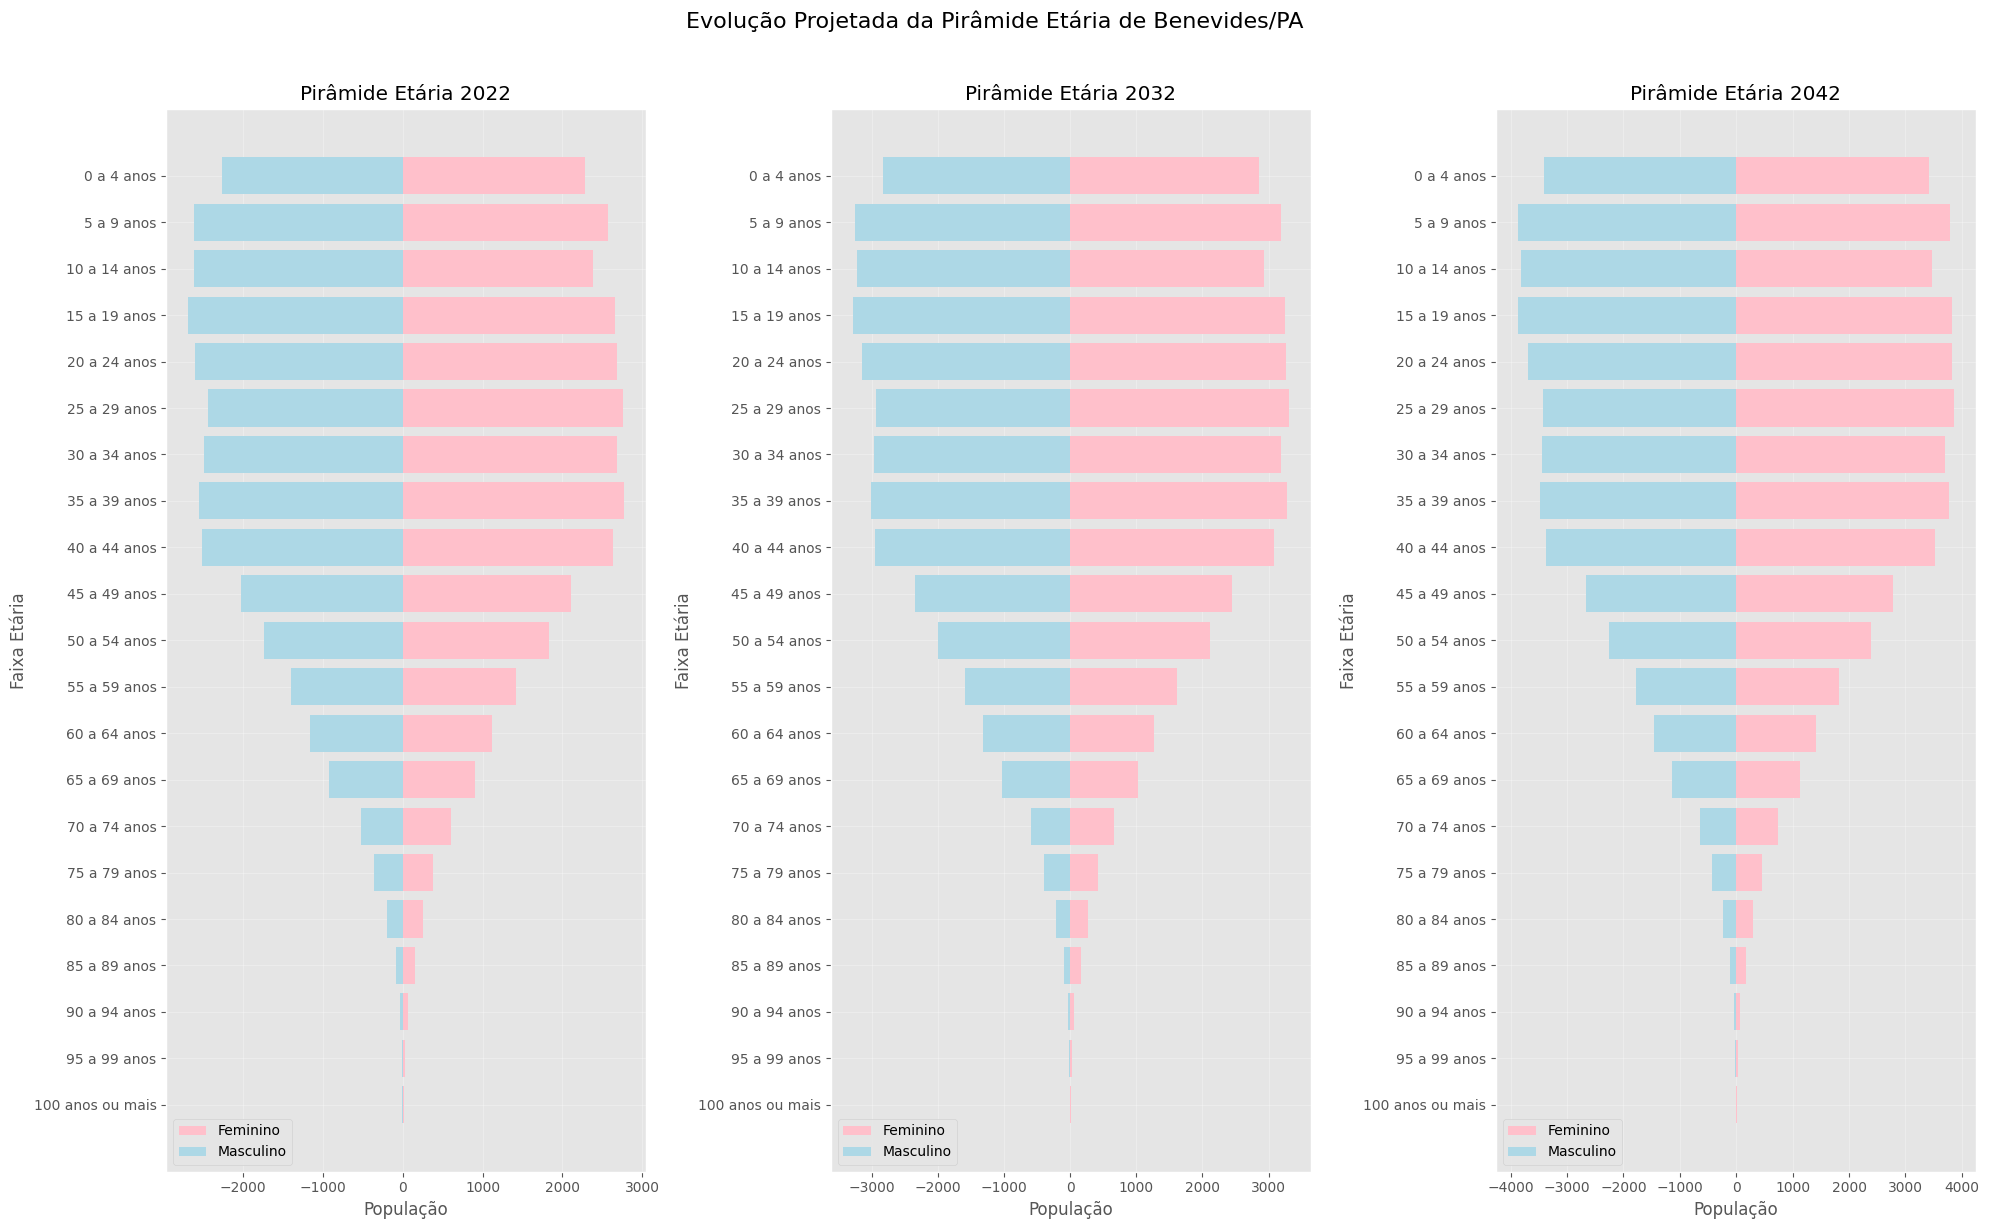


COMPARAÇÃO DE FAIXAS ETÁRIAS (PROJEÇÕES)


,Faixa Etária,2022 Total,2032 Proj.,2042 Proj.,Cresc. 22-42 (%)
0,100 anos ou mais,19,19,20,5.3%
1,95 a 99 anos,36,37,39,8.3%
2,90 a 94 anos,94,100,106,12.8%
3,85 a 89 anos,239,257,276,15.5%
4,80 a 84 anos,452,491,532,17.7%
5,75 a 79 anos,739,812,886,19.9%
6,70 a 74 anos,"1,131","1,255","1,379",21.9%
7,65 a 69 anos,"1,830","2,049","2,268",23.9%
8,60 a 64 anos,"2,281","2,576","2,873",26.0%
9,55 a 59 anos,"2,819","3,213","3,607",28.0%



ANÁLISE DE EDUCAÇÃO E PROJEÇÕES

--------------------------------------------------
Arquivo: alfabetização.csv
--------------------------------------------------


,Situação,População(pessoas),Percentual,Município,Sigla UF,Código do Município
0,Alfabetizados,46122,94.44,Benevides,PA,1501501
1,Não alfabetizados,2715,5.56,Benevides,PA,1501501



--------------------------------------------------
Arquivo: nível de instrução.csv
--------------------------------------------------


,Nível de instrução,População (pessoas),Município,Sigla UF,Código do Município
0,Sem instrução e fundamental incompleto,16046,Benevides,PA,1501501
1,Fundamental completo e médio incompleto,10577,Benevides,PA,1501501


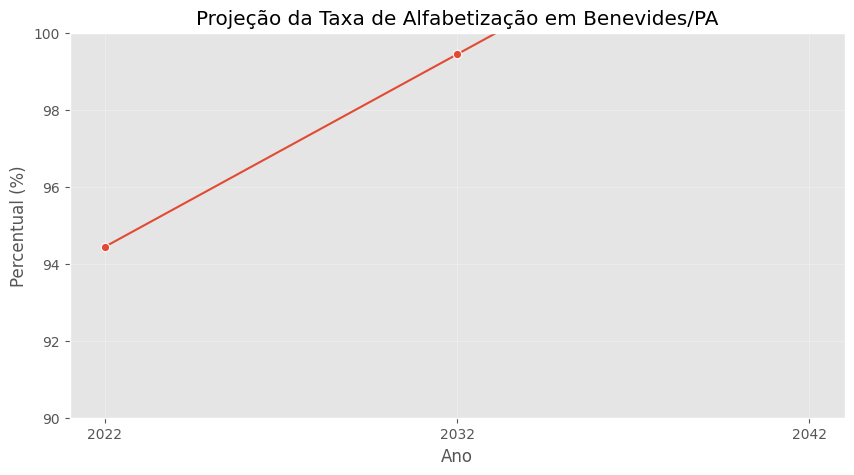

<Figure size 1200x600 with 0 Axes>

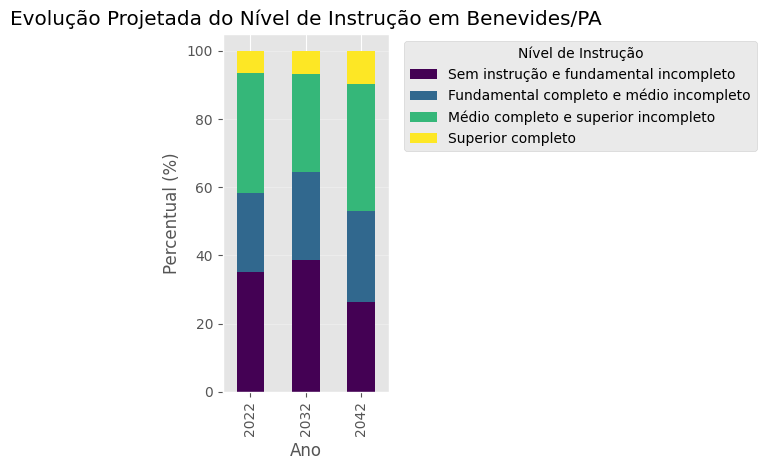


EVOLUÇÃO PROJETADA DO NÍVEL DE INSTRUÇÃO (%)


,2022,2032,2042
Sem instrução e fundamental incompleto,35.1%,38.8%,26.3%
Fundamental completo e médio incompleto,23.1%,25.6%,26.9%
Médio completo e superior incompleto,35.3%,28.8%,37.3%
Superior completo,6.6%,6.9%,9.6%



ANÁLISE DE DOMICÍLIOS E PROJEÇÕES

--------------------------------------------------
Arquivo: características dos domicílios.csv
--------------------------------------------------


,Característica,Não possui(%),Possui(%),Município,Sigla UF,Código do Município
0,Conectados à rede de esgoto,92.83,7.17,Benevides,PA,1501501
1,Abastecidos pela rede geral de água,29.35,70.65,Benevides,PA,1501501



--------------------------------------------------
Arquivo: composição domiciliar.csv
--------------------------------------------------


,Composição domiciliar,Porcentagem de domicílios,Município,Sigla UF,Código do Município
0,domicílios com 1 morador,1532,Benevides,PA,1501501
1,domicílios com cônjuges do mesmo sexo,5,Benevides,PA,1501501


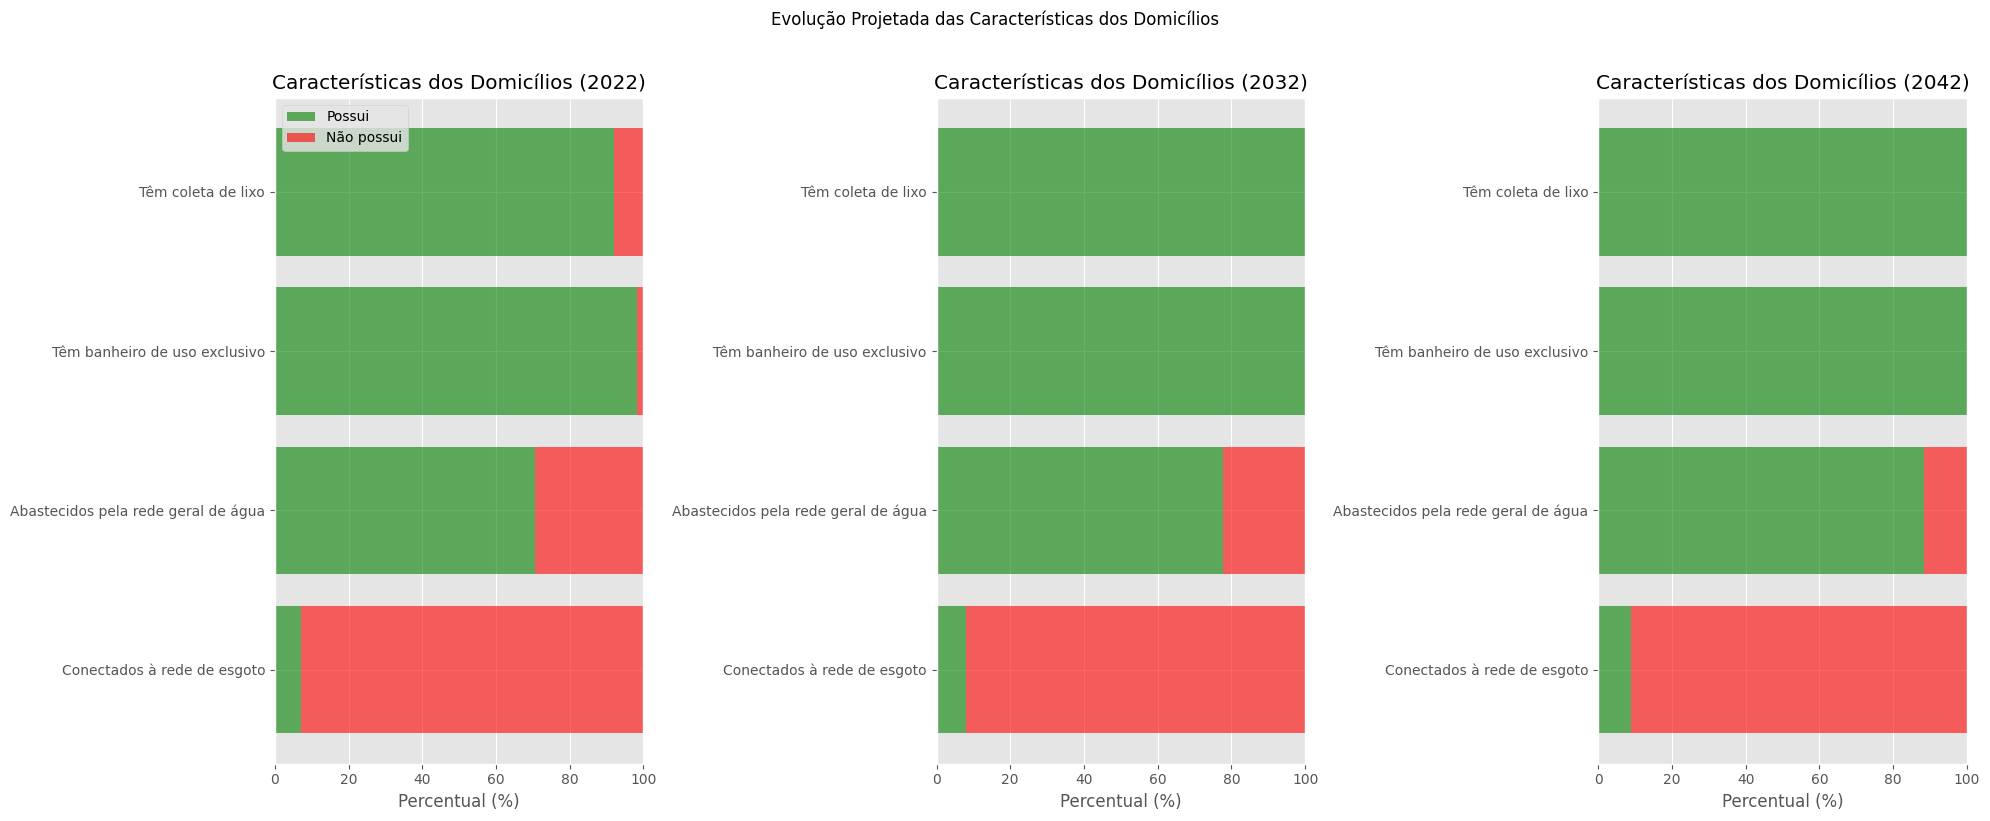


EVOLUÇÃO DAS CARACTERÍSTICAS DOS DOMICÍLIOS


,Característica,2022 Possui (%),2032 Proj. (%),2042 Proj. (%),Variação 22-42 (pp)
0,Conectados à rede de esgoto,7.2%,7.9%,9.0%,1.8
1,Abastecidos pela rede geral de água,70.7%,77.7%,88.3%,17.7
2,Têm banheiro de uso exclusivo,98.3%,100.0%,100.0%,1.7
3,Têm coleta de lixo,92.0%,100.0%,100.0%,8.0


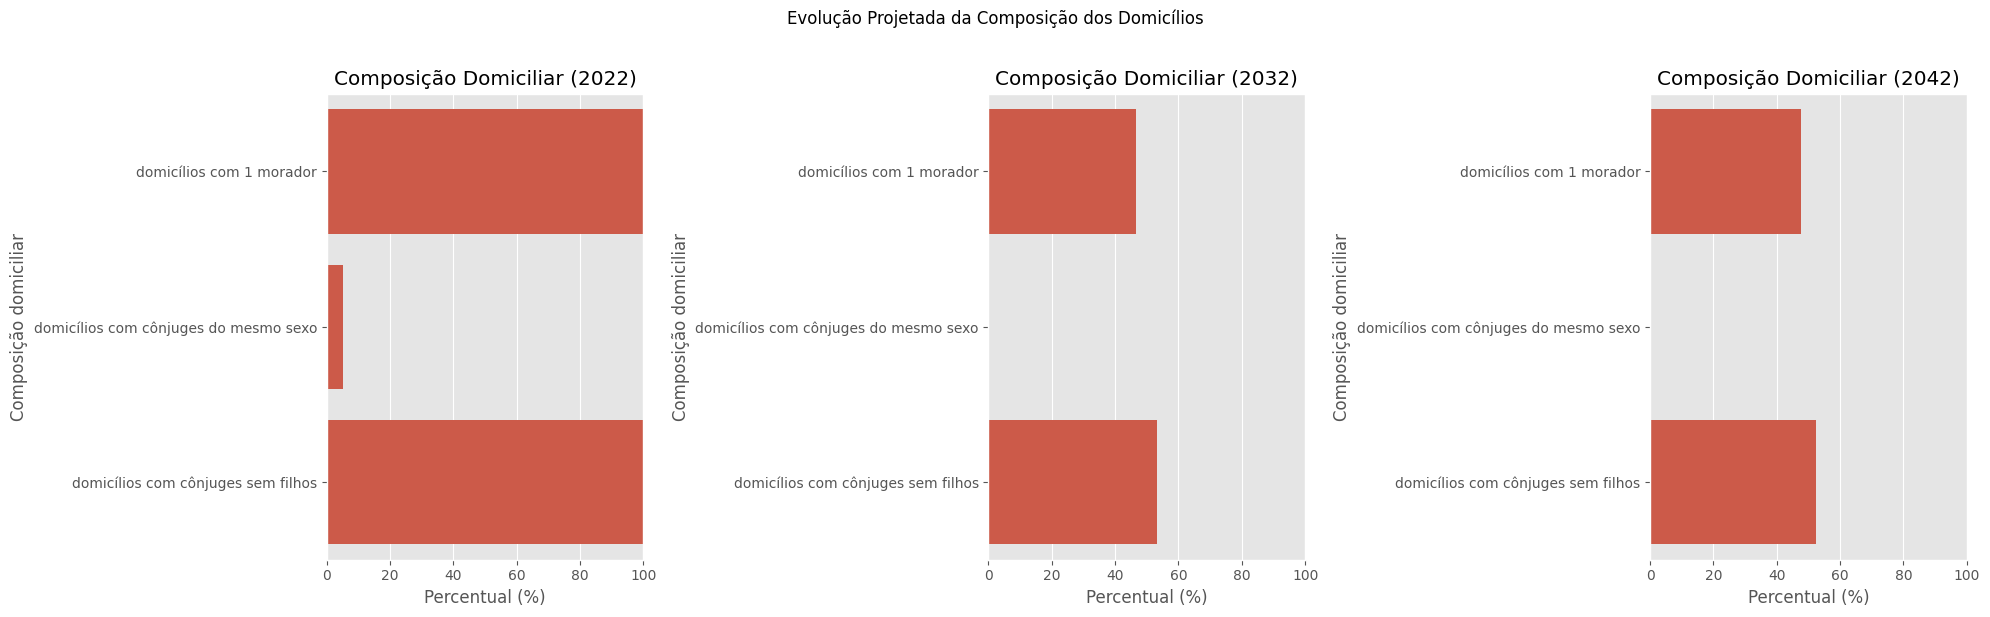


EVOLUÇÃO DA COMPOSIÇÃO DOMICILIAR


,Composição,2022 (%),2032 Proj. (%),2042 Proj. (%),Variação 22-42 (pp)
0,domicílios com 1 morador,1532.0%,46.7%,47.6%,-1484.4
1,domicílios com cônjuges do mesmo sexo,5.0%,0.1%,0.1%,-4.9
2,domicílios com cônjuges sem filhos,1824.0%,53.2%,52.3%,-1771.7



ANÁLISE COMPLETA CONCLUÍDA


In [ ]:
 # Célula 8: Execução
print("INICIANDO ANÁLISE DO CENSO IBGE 2022 - BENEVIDES/PA")
analise_completa()